In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# Explicitly define the project root
PROJECT_ROOT = Path(
    r"C:\Users\HUAWEI\Desktop\xauusd-direction-classifier"
)

# Add project root to Python's import path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())
print("src folder exists:", (PROJECT_ROOT / "src").exists())
print("data_processing.py exists:",
      (PROJECT_ROOT / "src" / "data_processing.py").exists())


from src.data_processing import (
    load_raw_data,
    clean_data,
    validate_data,
)


print("Imports successful.")

Project root: C:\Users\HUAWEI\Desktop\xauusd-direction-classifier
Project root exists: True
src folder exists: True
data_processing.py exists: True
Imports successful.


In [2]:
df = load_raw_data(
    PROJECT_ROOT / "data" / "raw" / "XAU_1h_data.csv"
)

df = clean_data(df)

validate_data(df)

print(f"Dataset shape: {df.shape}")
print(f"Start date: {df['date'].min()}")
print(f"End date: {df['date'].max()}")

df.head()

Dataset shape: (125206, 6)
Start date: 2004-06-11 07:00:00
End date: 2026-01-30 23:00:00


,date,open,high,low,close,volume
0,2004-06-11 07:00:00,384.0,384.3,383.3,383.8,44
1,2004-06-11 08:00:00,383.8,384.3,383.1,383.1,41
2,2004-06-11 09:00:00,383.1,384.1,382.8,383.1,55
3,2004-06-11 10:00:00,383.0,383.8,383.0,383.6,33
4,2004-06-11 11:00:00,383.6,383.8,383.5,383.6,23


In [3]:
df.describe()

,date,open,high,low,close,volume
count,125206,125206.000000,125206.000000,125206.000000,125206.000000,125206.000000
mean,2015-04-22 09:57:08.950689536,1419.139856,1421.110693,1417.100514,1419.156079,3900.007068
min,2004-06-11 07:00:00,381.300000,382.000000,381.100000,381.800000,1.000000
25%,2009-12-08 11:15:00,1072.982500,1074.242500,1071.660000,1072.970000,795.000000
50%,2015-05-08 01:30:00,1304.115000,1305.475000,1302.705000,1304.115000,2555.000000
75%,2020-09-02 13:45:00,1752.125000,1754.555000,1749.867500,1752.160000,4729.000000
max,2026-01-30 23:00:00,5562.460000,5597.600000,5554.690000,5562.390000,406226.000000
std,NaN,672.388310,673.498930,671.188591,672.422937,6763.227344


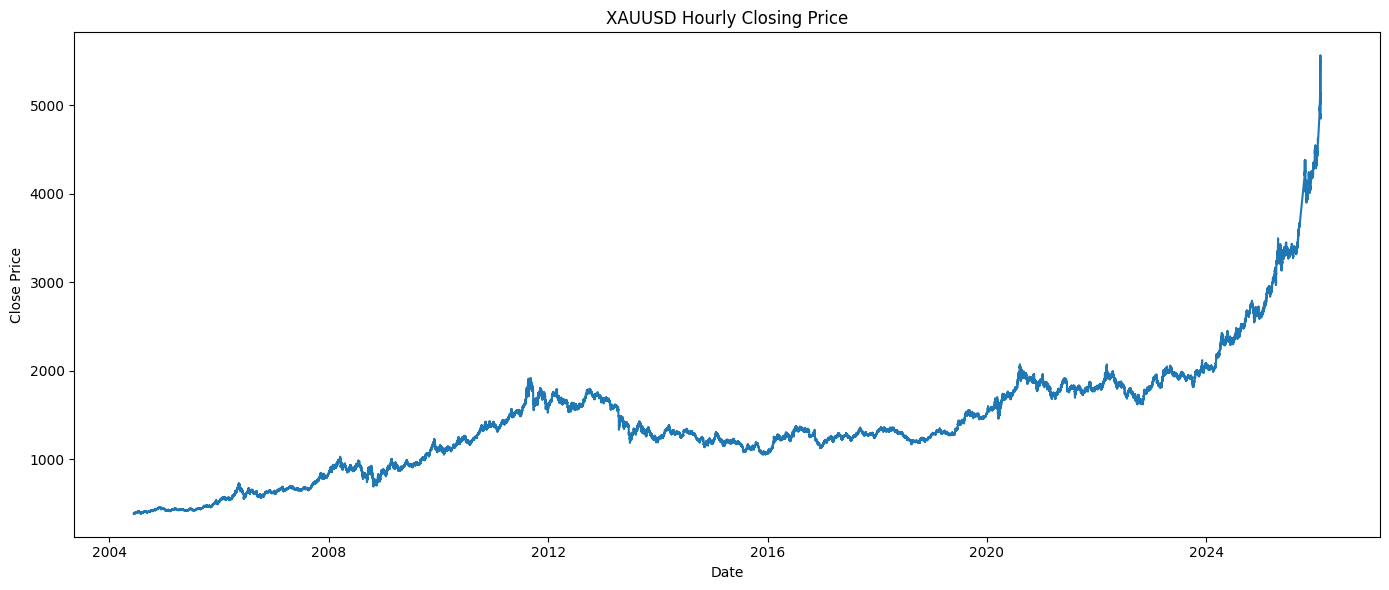

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(df["date"], df["close"])

plt.title("XAUUSD Hourly Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.tight_layout()
plt.show()

In [5]:
df["return"] = df["close"].pct_change()

df["return"].describe()

count    125205.000000
mean          0.000023
std           0.002322
min          -0.057189
25%          -0.000831
50%           0.000000
75%           0.000899
max           0.147459
Name: return, dtype: float64

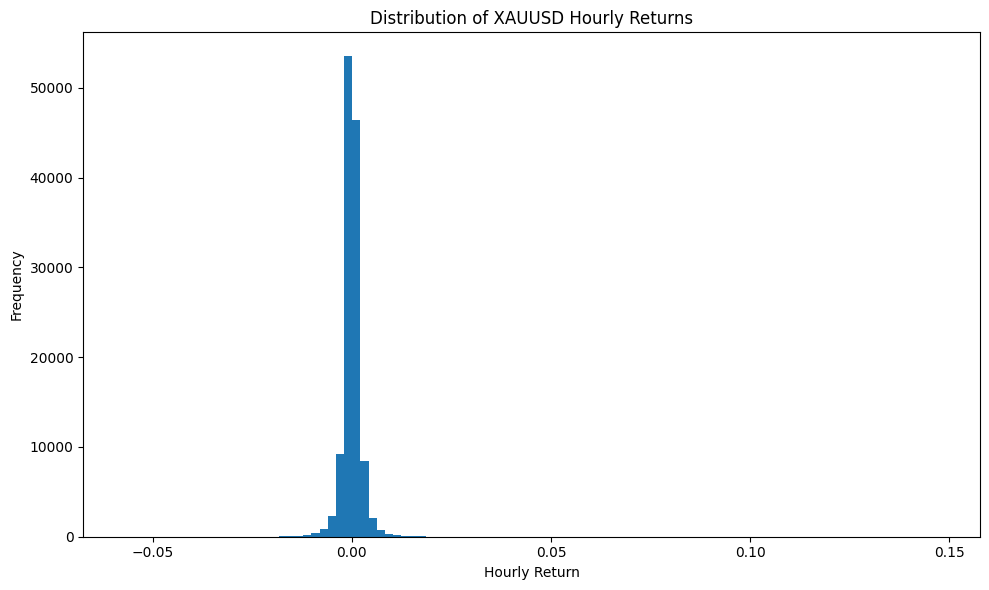

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(df["return"].dropna(), bins=100)

plt.title("Distribution of XAUUSD Hourly Returns")
plt.xlabel("Hourly Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Project root: c:\Users\HUAWEI\Desktop\xauusd-direction-classifier
Data path: c:\Users\HUAWEI\Desktop\xauusd-direction-classifier\data\raw\XAU_1h_data.csv
Data file exists: True

FEATURE CORRELATION MATRIX
                return_1h  return_3h  return_6h  return_12h  return_24h  \
return_1h           1.000      0.576      0.407       0.288       0.213   
return_3h           0.576      1.000      0.704       0.499       0.370   
return_6h           0.407      0.704      1.000       0.708       0.520   
return_12h          0.288      0.499      0.708       1.000       0.717   
return_24h          0.213      0.370      0.520       0.717       1.000   
momentum_3h         0.576      1.000      0.704       0.499       0.370   
momentum_6h         0.407      0.704      1.000       0.708       0.520   
momentum_12h        0.288      0.499      0.708       1.000       0.717   
momentum_24h        0.213      0.370      0.520       0.717       1.000   
body_size           0.959      0.553      0.3

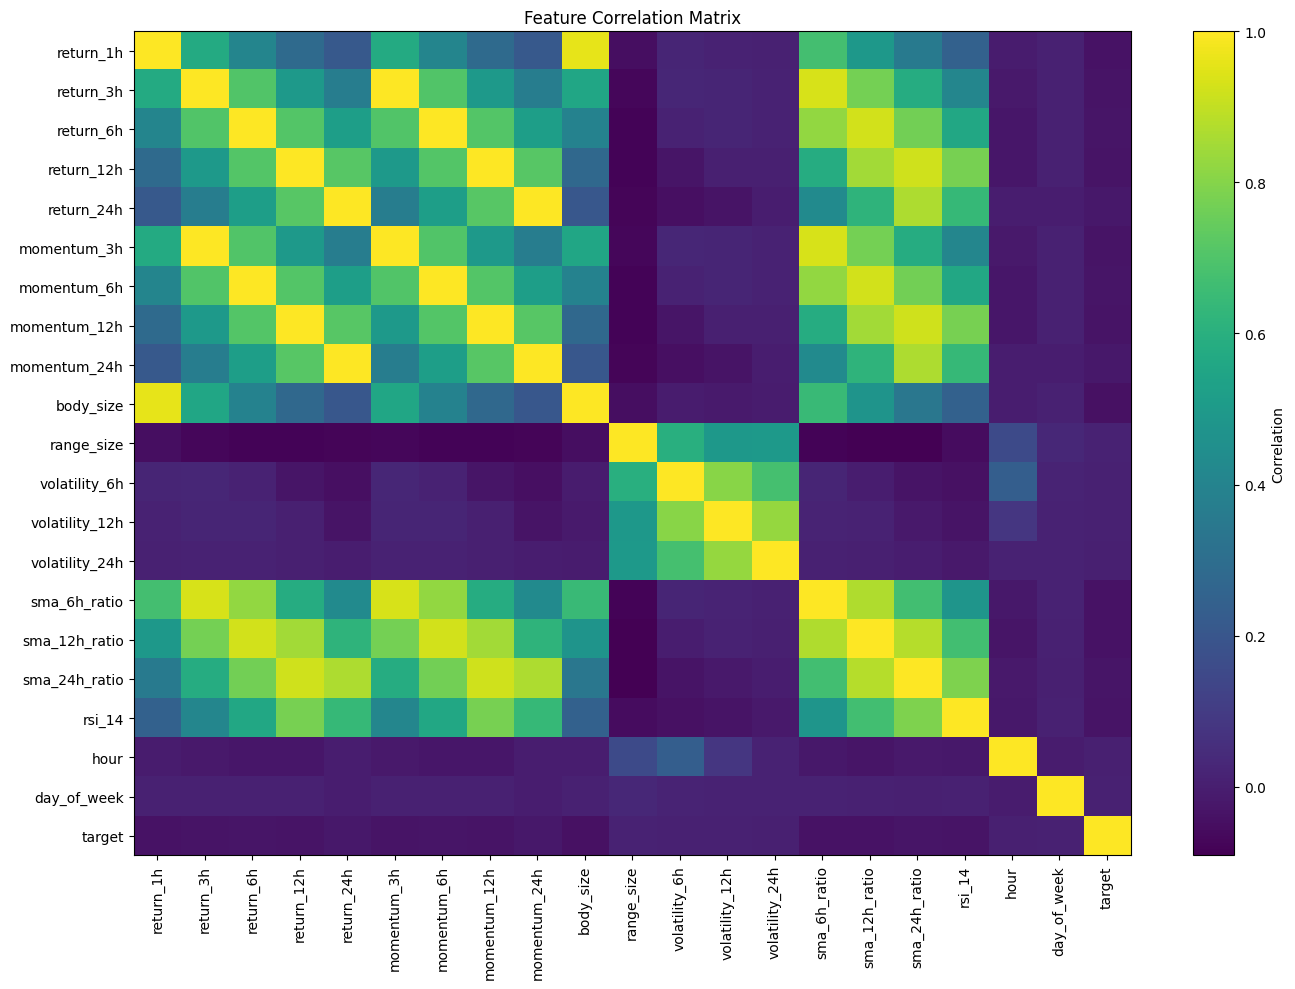

In [10]:
# Feature Correlation Analysis

from pathlib import Path
import sys
import matplotlib.pyplot as plt


# --------------------------------------------------
# FIND PROJECT ROOT
# --------------------------------------------------

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# --------------------------------------------------
# PROJECT IMPORTS
# --------------------------------------------------

from src.features import (
    FEATURE_COLUMNS,
    build_modeling_dataset,
)

from src.data_processing import (
    load_raw_data,
    clean_data,
)


# --------------------------------------------------
# CREATE ABSOLUTE DATA PATH
# --------------------------------------------------

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "XAU_1h_data.csv"
)


# --------------------------------------------------
# LOAD AND PREPARE DATA
# --------------------------------------------------

print("Project root:", PROJECT_ROOT)
print("Data path:", RAW_DATA_PATH)
print("Data file exists:", RAW_DATA_PATH.exists())

raw_data = load_raw_data(RAW_DATA_PATH)

cleaned_data = clean_data(raw_data)

modeling_data = build_modeling_dataset(cleaned_data)


# --------------------------------------------------
# CALCULATE CORRELATIONS
# --------------------------------------------------

correlation_matrix = modeling_data[
    FEATURE_COLUMNS + ["target"]
].corr()


# --------------------------------------------------
# DISPLAY CORRELATION VALUES
# --------------------------------------------------

print("\nFEATURE CORRELATION MATRIX")
print("=" * 60)

print(correlation_matrix.round(3))


# --------------------------------------------------
# PLOT CORRELATION MATRIX
# --------------------------------------------------

plt.figure(figsize=(14, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto",
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

c:\Users\HUAWEI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.9.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\HUAWEI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.9.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\HUAWEI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator 

Model loaded successfully.
Validation observations: 18777

PERMUTATION FEATURE IMPORTANCE
           feature  importance_mean  importance_std
0        body_size         0.004974        0.001690
1        return_1h         0.004910        0.001808
2       return_12h         0.003760        0.001911
3   volatility_24h         0.001630        0.000302
4     sma_6h_ratio         0.001587        0.000596
5   volatility_12h         0.001193        0.000295
6             hour         0.001161        0.001390
7      day_of_week         0.000927        0.000742
8           rsi_14         0.000927        0.000985
9        return_6h         0.000767        0.000455
10       return_3h         0.000660        0.001083
11      return_24h         0.000511        0.000460
12      range_size         0.000447        0.000914
13   sma_24h_ratio         0.000053        0.000400
14     momentum_3h         0.000000        0.000000
15    momentum_12h         0.000000        0.000000
16     momentum_6h        

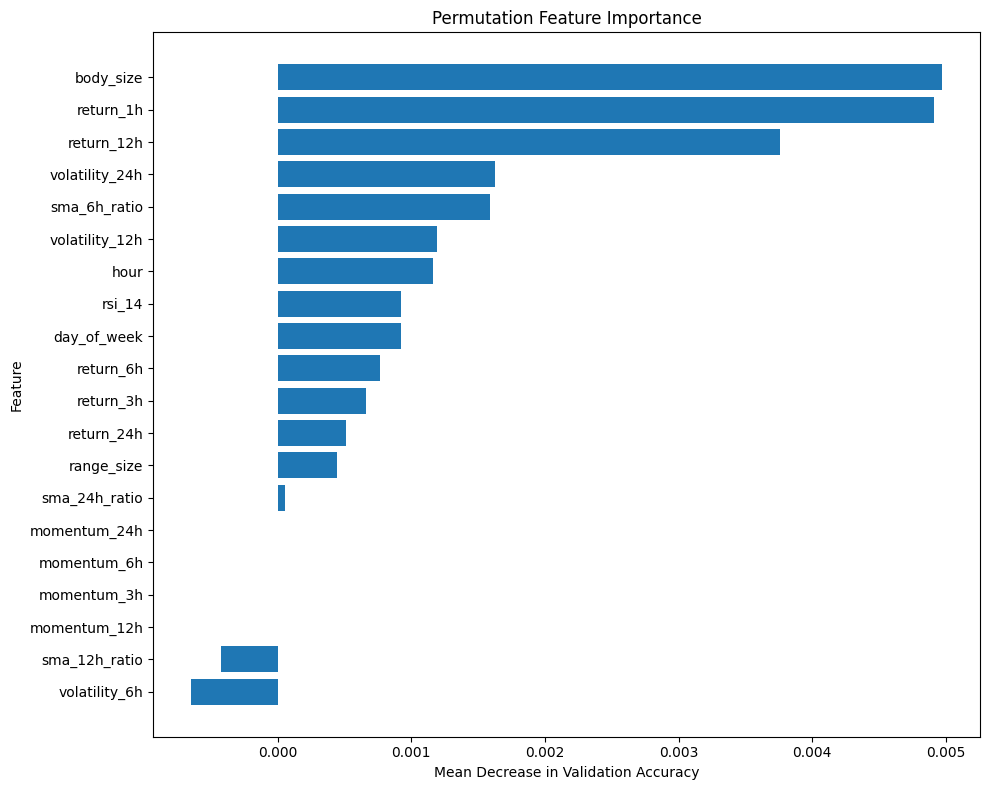

In [11]:
# Permutation Feature Importance Analysis

from pathlib import Path
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance


# --------------------------------------------------
# FIND PROJECT ROOT
# --------------------------------------------------

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# --------------------------------------------------
# PROJECT IMPORTS
# --------------------------------------------------

from src.data_processing import (
    load_raw_data,
    clean_data,
)

from src.features import (
    FEATURE_COLUMNS,
    build_modeling_dataset,
)

from src.train import chronological_train_val_test_split


# --------------------------------------------------
# FILE PATHS
# --------------------------------------------------

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "XAU_1h_data.csv"
)

MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "gradient_boosting_model.joblib"
)


# --------------------------------------------------
# LOAD AND PREPARE DATA
# --------------------------------------------------

raw_data = load_raw_data(RAW_DATA_PATH)

cleaned_data = clean_data(raw_data)

modeling_data = build_modeling_dataset(cleaned_data)


# --------------------------------------------------
# CREATE SAME CHRONOLOGICAL SPLIT
# --------------------------------------------------

train_df, val_df, test_df = chronological_train_val_test_split(
    modeling_data
)


X_val = val_df[FEATURE_COLUMNS]

y_val = val_df["target"]


# --------------------------------------------------
# LOAD TRAINED MODEL
# --------------------------------------------------

model = joblib.load(MODEL_PATH)

print("Model loaded successfully.")

print(f"Validation observations: {len(X_val)}")


# --------------------------------------------------
# CALCULATE PERMUTATION IMPORTANCE
# --------------------------------------------------

importance_results = permutation_importance(
    model,
    X_val,
    y_val,
    scoring="accuracy",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)


# --------------------------------------------------
# CREATE RESULTS DATAFRAME
# --------------------------------------------------

feature_importance = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "importance_mean": importance_results.importances_mean,
        "importance_std": importance_results.importances_std,
    }
)


feature_importance = feature_importance.sort_values(
    by="importance_mean",
    ascending=False,
).reset_index(drop=True)


# --------------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------------

print("\nPERMUTATION FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance.round(6))


# --------------------------------------------------
# PLOT FEATURE IMPORTANCE
# --------------------------------------------------

plot_data = feature_importance.sort_values(
    by="importance_mean",
    ascending=True,
)


plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["feature"],
    plot_data["importance_mean"],
)

plt.xlabel("Mean Decrease in Validation Accuracy")

plt.ylabel("Feature")

plt.title("Permutation Feature Importance")

plt.tight_layout()

plt.show()